In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    sales = pd.read_csv("store_sales.csv", parse_dates=["order_date"], dtype={"category": "category", "product": "category"})
except FileNotFoundError:
    print("Error: 'store_sales.csv' not found. Please ensure the file is in the correct directory.")

In [2]:
# Display the first 5 rows of the store_sales DataFrame
sales.head(5)

,order_id,product,category,quantity,price,order_date
0,1,Laptop,Electronics,1,999.99,2023-02-01
1,2,T-shirt,Clothing,2,19.99,2023-02-01
2,3,Headphones,Electronics,3,49.99,2023-02-02
3,4,Jacket,Clothing,1,89.99,2023-02-02
4,5,Book A,Books,4,14.99,2023-02-03


In [3]:
# Check data types and missing values
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_id    10 non-null     int64         
 1   product     10 non-null     category      
 2   category    10 non-null     category      
 3   quantity    10 non-null     int64         
 4   price       10 non-null     float64       
 5   order_date  10 non-null     datetime64[ns]
dtypes: category(2), datetime64[ns](1), float64(1), int64(2)
memory usage: 984.0 bytes


In [4]:
# Group the data by category and calculate the total quantity sold for each category
quantity_by_category = sales.groupby("category", observed=False)["quantity"].sum().sort_values(ascending=False)

quantity_by_category

category
Books          9
Electronics    9
Clothing       6
Name: quantity, dtype: int64

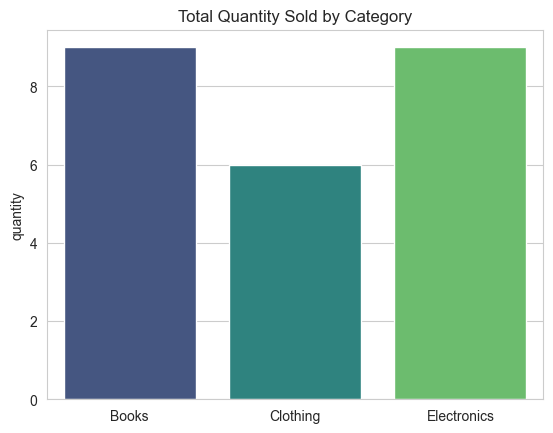

In [5]:
# Optional: Visualize total quantity sold by category
sns.barplot(data=sales, x="category", y="quantity", hue="category", estimator=sum, palette="viridis", errorbar=None)

plt.title("Total Quantity Sold by Category")
plt.xlabel("")

plt.show()

In [6]:
# Display the top 2 categories by total quantity sold.
quantity_by_category.nlargest(2)

category
Books          9
Electronics    9
Name: quantity, dtype: int64

In [7]:
# Group the data by category and calculate the average price for each category.
avg_price_by_category = sales.groupby("category", observed=False)["price"].mean().round(2).sort_values(ascending=False)

avg_price_by_category

category
Electronics    263.99
Clothing        56.66
Books           12.49
Name: price, dtype: float64

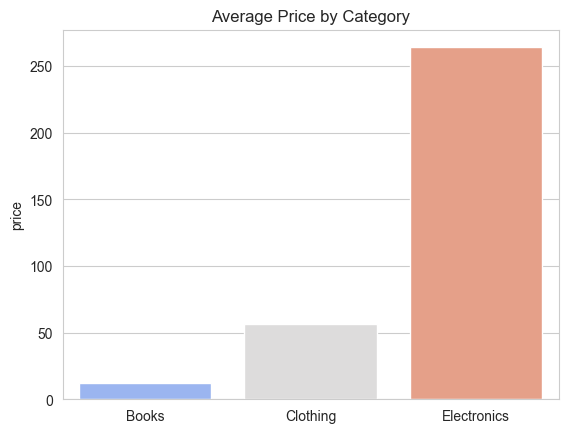

In [8]:
sns.barplot(data=sales, x="category", y="price", hue="category", palette="coolwarm", errorbar=None)

plt.title("Average Price by Category")
plt.xlabel("")

plt.show()

In [9]:
# Create a new DataFrame with orders where the price is greater than 50.
biggest_sales = sales[sales["price"] > 50].copy()

biggest_sales.head()

,order_id,product,category,quantity,price,order_date
0,1,Laptop,Electronics,1,999.99,2023-02-01
3,4,Jacket,Clothing,1,89.99,2023-02-02
6,7,Shoes,Clothing,3,59.99,2023-02-04
7,8,Monitor,Electronics,1,199.99,2023-02-04


In [10]:
# Calculate the total sales value for these filtered orders
biggest_sales["total_sales"] = biggest_sales["quantity"] * biggest_sales["price"]

biggest_sales["total_sales"].sum()

np.float64(1469.94)